In [46]:
import pandas as pd
import numpy as np
from google.colab import files

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import matplotlib.patches as mpatches


# Color palette
NAVY   = '#1B2A4A'
BLUE   = '#2563EB'
ACCENT = '#3B82F6'
GREEN  = '#16A34A'
RED    = '#DC2626'
GRAY   = '#6B7280'
AMBER  = '#D97706'
LIGHT  = '#EFF6FF'

plt.rcParams['font.family'] = 'DejaVu Sans'

In [48]:
# 1. Load 4 Tabel Utama
df_loads = pd.read_csv('loads.csv')
df_trips = pd.read_csv('trips.csv')
df_routes = pd.read_csv('routes.csv')
df_customers = pd.read_csv('customers.csv')

# Masukkan ke dalam dictionary untuk memfasilitasi iterasi observasi
datasets = {
    'Loads': df_loads,
    'Trips': df_trips,
    'Routes': df_routes,
    'Customers': df_customers
}

print("=== OBSERVASI KUALITAS DATA & INTEGRITAS TABEL ===\n")

# 2. Iterasi Pengecekan Ukuran, Missing Values, dan Duplikat
for name, df in datasets.items():
    print(f"--- Table: {name.upper()} ---")
    print(f"1. Shape (Baris, Kolom): {df.shape}")

    # Deteksi Missing Values
    missing_vals = df.isnull().sum()
    missing_filtered = missing_vals[missing_vals > 0]

    if missing_filtered.empty:
        print("2. Missing Values: Tidak terdeteksi (0)")
    else:
        print(f"2. Missing Values terdeteksi pada:\n{missing_filtered.to_string()}")

    # Deteksi Duplikasi Data
    duplicates = df.duplicated().sum()
    print(f"3. Baris Duplikat: {duplicates}\n")

=== OBSERVASI KUALITAS DATA & INTEGRITAS TABEL ===

--- Table: LOADS ---
1. Shape (Baris, Kolom): (85410, 12)
2. Missing Values: Tidak terdeteksi (0)
3. Baris Duplikat: 0

--- Table: TRIPS ---
1. Shape (Baris, Kolom): (85410, 12)
2. Missing Values terdeteksi pada:
driver_id     1714
truck_id      1672
trailer_id    1680
3. Baris Duplikat: 0

--- Table: ROUTES ---
1. Shape (Baris, Kolom): (58, 9)
2. Missing Values: Tidak terdeteksi (0)
3. Baris Duplikat: 0

--- Table: CUSTOMERS ---
1. Shape (Baris, Kolom): (200, 8)
2. Missing Values: Tidak terdeteksi (0)
3. Baris Duplikat: 0



In [49]:
# OUTLIER & CONSISTENCY DETECTION
print("=" * 65)
print("  OUTLIER & CONSISTENCY DETECTION")
print("=" * 65)

# Implied speed as logical consistency check
df_trips['implied_speed_mph'] = (
    df_trips['actual_distance_miles'] / df_trips['actual_duration_hours']
)

too_fast        = df_trips[df_trips['implied_speed_mph'] > 85]
too_slow        = df_trips[df_trips['implied_speed_mph'] < 10]
negative_dur    = df_trips[df_trips['actual_duration_hours'] <= 0]

print(f"\n  Logical Consistency Check (Implied Speed):")
print(f"    Negative / Zero Duration  : {len(negative_dur):,} rows")
print(f"    Speed > 85 mph (too fast) : {len(too_fast):,} rows")
print(f"    Speed < 10 mph (too slow) : {len(too_slow):,} rows")

# IQR method — domain-aware: lower bound clamped to 0
# Rationale: duration and distance are physically non-negative.
# Right-skewed distributions often produce negative IQR lower bounds
# (Q1 - 1.5*IQR < 0), which are statistically valid but domain-invalid.
# Clamping to max(0, lb) aligns the statistical method with physical reality.
for col in ['actual_duration_hours', 'actual_distance_miles']:
    Q1, Q3  = df_trips[col].quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    lb_raw  = Q1 - 1.5 * IQR
    lb      = max(0, lb_raw)   # clamp: cannot have negative duration or distance
    ub      = Q3 + 1.5 * IQR
    outs    = df_trips[(df_trips[col] < lb) | (df_trips[col] > ub)]
    print(f"\n  IQR Outliers [{col}]:")
    print(f"    Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"    Lower Bound: {lb:.2f}")
    print(f"    Upper Bound: {ub:.2f}")
    print(f"    Outliers   : {len(outs):,} rows ({len(outs)/len(df_trips)*100:.2f}%)")

# Duplicate check
for name, df in datasets.items():
    d = df.duplicated().sum()
    print(f"\n  Duplicate rows [{name}]: {d}")


  OUTLIER & CONSISTENCY DETECTION

  Logical Consistency Check (Implied Speed):
    Negative / Zero Duration  : 0 rows
    Speed > 85 mph (too fast) : 0 rows
    Speed < 10 mph (too slow) : 0 rows

  IQR Outliers [actual_duration_hours]:
    Q1=12.60, Q3=36.90, IQR=24.30
    Lower Bound: 0.00
    Upper Bound: 73.35
    Outliers   : 0 rows (0.00%)

  IQR Outliers [actual_distance_miles]:
    Q1=717.00, Q3=2147.00, IQR=1430.00
    Lower Bound: 0.00
    Upper Bound: 4292.00
    Outliers   : 0 rows (0.00%)

  Duplicate rows [Loads]: 0

  Duplicate rows [Trips]: 0

  Duplicate rows [Routes]: 0

  Duplicate rows [Customers]: 0


In [50]:
# DATA WRANGLING
print("=" * 65)
print("  DATA WRANGLING — CLEANING & TRANSFORMATION")
print("=" * 65)

# Before state
before_missing = df_trips[['driver_id','truck_id','trailer_id']].isnull().sum().sum()
print(f"\n  [BEFORE] Total missing in fleet columns: {before_missing:,}")

# Fix 1: Impute missing fleet IDs
df_trips_clean = df_trips.copy()
fleet_cols     = ['driver_id', 'truck_id', 'trailer_id']
df_trips_clean[fleet_cols] = df_trips_clean[fleet_cols].fillna('Unknown')

# After state
after_missing  = df_trips_clean[['driver_id','truck_id','trailer_id']].isnull().sum().sum()
print(f"  [AFTER]  Total missing in fleet columns: {after_missing:,}")
print(f"  Improvement: {before_missing - after_missing:,} values imputed ({((before_missing-after_missing)/max(before_missing,1))*100:.1f}%)")

# Fix 2: Remove logical errors (negative duration)
before_rows = len(df_trips_clean)
df_trips_clean = df_trips_clean[df_trips_clean['actual_duration_hours'] > 0]
removed = before_rows - len(df_trips_clean)
print(f"\n  Rows removed (negative duration): {removed:,}")
print(f"  Dataset integrity: {len(df_trips_clean):,} / {before_rows:,} rows retained ({len(df_trips_clean)/before_rows*100:.2f}%)")

# Fix 3: Ensure correct data types
if 'scheduled_departure' in df_trips_clean.columns:
    df_trips_clean['scheduled_departure'] = pd.to_datetime(df_trips_clean['scheduled_departure'], errors='coerce')
if 'actual_arrival' in df_trips_clean.columns:
    df_trips_clean['actual_arrival'] = pd.to_datetime(df_trips_clean['actual_arrival'], errors='coerce')

print("\n  Data types corrected for temporal columns.")


  DATA WRANGLING — CLEANING & TRANSFORMATION

  [BEFORE] Total missing in fleet columns: 5,066
  [AFTER]  Total missing in fleet columns: 0
  Improvement: 5,066 values imputed (100.0%)

  Rows removed (negative duration): 0
  Dataset integrity: 85,410 / 85,410 rows retained (100.00%)

  Data types corrected for temporal columns.


In [51]:
# DATA INTEGRATION (MASTER TABLE)
print("=" * 65)
print("  DATA INTEGRATION — BUILDING MASTER TABLE")
print("=" * 65)

# Step 1: loads + trips (inner join → only trips with a load)
df_master = pd.merge(df_loads, df_trips_clean, on='load_id', how='inner')
print(f"  Step 1 [Loads + Trips]   : {df_master.shape[0]:,} rows, {df_master.shape[1]} cols")

# Step 2: + routes
df_master = pd.merge(df_master, df_routes, on='route_id', how='left')
print(f"  Step 2 [+ Routes]        : {df_master.shape[0]:,} rows, {df_master.shape[1]} cols")

# Step 3: + customers
df_master = pd.merge(df_master, df_customers, on='customer_id', how='left')
print(f"  Step 3 [+ Customers]     : {df_master.shape[0]:,} rows, {df_master.shape[1]} cols")

# Derived variables
# implied_speed_mph: computed speed from actual distance / duration
df_master['implied_speed_mph'] = df_master['actual_distance_miles'] / df_master['actual_duration_hours']

# efficiency_ratio: actual vs typical (planned) distance — column is 'typical_distance_miles'
df_master['efficiency_ratio'] = df_master['actual_distance_miles'] / df_master['typical_distance_miles']

# on_time: derived dari perbandingan actual_duration_hours vs typical_transit_days
# typical_transit_days dikonversi ke jam (× 24) sebagai benchmark SLA
# on_time = True jika actual duration <= SLA threshold (typical_transit_days × 24 jam)
df_master['sla_hours']  = df_master['typical_transit_days'] * 24
df_master['on_time']    = df_master['actual_duration_hours'] <= df_master['sla_hours']
df_master['delay_hours']= (df_master['actual_duration_hours'] - df_master['sla_hours']).clip(lower=0)

print(f"\n  Derived Variables Added:")
print(f"    ✔ efficiency_ratio — actual_distance_miles / typical_distance_miles")
print(f"    ✔ sla_hours        — typical_transit_days × 24 (benchmark durasi)")
print(f"    ✔ on_time          — True jika actual_duration_hours <= sla_hours")
print(f"    ✔ delay_hours      — jam keterlambatan (0 jika on time)")
print(f"\n  On-Time Rate     : {df_master['on_time'].mean()*100:.2f}%")
print(f"  Late Trips       : {(~df_master['on_time']).sum():,} dari {len(df_master):,}")
print(f"  Avg Delay (late) : {df_master[~df_master['on_time']]['delay_hours'].mean():.2f} jam")

print(f"\n  MASTER TABLE READY: {df_master.shape[0]:,} rows × {df_master.shape[1]} cols")
print(f"  Columns: {list(df_master.columns)}")


  DATA INTEGRATION — BUILDING MASTER TABLE
  Step 1 [Loads + Trips]   : 85,410 rows, 24 cols
  Step 2 [+ Routes]        : 85,410 rows, 32 cols
  Step 3 [+ Customers]     : 85,410 rows, 39 cols

  Derived Variables Added:
    ✔ efficiency_ratio — actual_distance_miles / typical_distance_miles
    ✔ sla_hours        — typical_transit_days × 24 (benchmark durasi)
    ✔ on_time          — True jika actual_duration_hours <= sla_hours
    ✔ delay_hours      — jam keterlambatan (0 jika on time)

  On-Time Rate     : 99.99%
  Late Trips       : 7 dari 85,410
  Avg Delay (late) : 0.17 jam

  MASTER TABLE READY: 85,410 rows × 43 cols
  Columns: ['load_id', 'customer_id', 'route_id', 'load_date', 'load_type', 'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge', 'accessorial_charges', 'load_status', 'booking_type', 'trip_id', 'driver_id', 'truck_id', 'trailer_id', 'dispatch_date', 'actual_distance_miles', 'actual_duration_hours', 'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status'

In [52]:
df_master.head(10)

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,...,customer_type,credit_terms_days,primary_freight_type,account_status,contract_start_date,annual_revenue_potential,efficiency_ratio,sla_hours,on_time,delay_hours
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,...,Spot,15,Electronics,Active,2021-05-25,1853299,1.033832,48,True,0.0
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,...,Spot,60,Electronics,Active,2021-11-22,1550411,0.992293,24,True,0.0
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,...,Spot,30,Automotive,Active,2021-02-03,1894559,1.075901,96,True,0.0
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,...,Dedicated,45,Consumer Goods,Active,2020-06-24,3743209,1.065379,24,True,0.0
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,...,Contract,45,Electronics,Active,2021-09-24,1877338,1.032689,72,True,0.0
5,LOAD00000006,CUST00193,RTE00004,2022-01-01,Refrigerated,34671,10,3582.78,383.23,75,...,Spot,30,Automotive,Active,2020-02-29,254254,0.980169,72,True,0.0
6,LOAD00000007,CUST00169,RTE00038,2022-01-01,Dry Van,14530,4,3872.46,314.64,150,...,Dedicated,15,Consumer Goods,Active,2021-10-31,819863,1.029748,48,True,0.0
7,LOAD00000008,CUST00049,RTE00016,2022-01-01,Refrigerated,16927,26,5914.90,463.93,100,...,Spot,45,Food/Beverage,Active,2020-01-30,4744463,1.006962,96,True,0.0
8,LOAD00000009,CUST00075,RTE00025,2022-01-01,Refrigerated,38964,3,4759.42,565.38,150,...,Contract,30,General,Inactive,2021-04-20,4147781,1.027061,120,True,0.0
9,LOAD00000010,CUST00079,RTE00025,2022-01-01,Refrigerated,29233,8,5723.39,565.38,50,...,Spot,15,Electronics,Active,2020-10-10,899971,1.078637,120,True,0.0


  DESCRIPTIVE STATISTICS — KEY OPERATIONAL METRICS
                         count      mean      std     min      25%     50%       75%       max  median  skewness  kurtosis   cv_%
actual_duration_hours  85410.0    25.015   14.192   1.400   12.600    23.0    36.900    67.800    23.0     0.315    -0.896  56.73
actual_distance_miles  85410.0  1430.268  801.932  90.000  717.000  1297.5  2147.000  3391.000  1297.5     0.259    -1.010  56.07
implied_speed_mph      85410.0    57.506    4.341  48.947   53.758    57.5    61.257    67.143    57.5     0.001    -1.193   7.55

  CV% = Coefficient of Variation (std/mean × 100). Lower = more consistent.


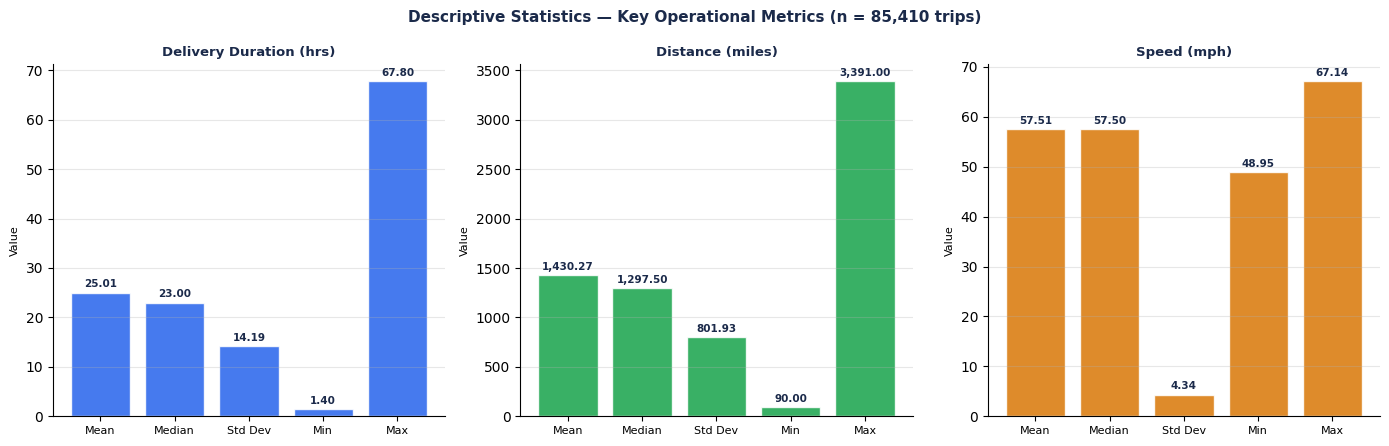

In [53]:
# DESCRIPTIVE STATISTICS
print("=" * 65)
print("  DESCRIPTIVE STATISTICS — KEY OPERATIONAL METRICS")
print("=" * 65)

metrics = ['actual_duration_hours', 'actual_distance_miles', 'implied_speed_mph']
metrics = [m for m in metrics if m in df_master.columns]

desc = df_master[metrics].describe().T
desc['median']   = df_master[metrics].median()
desc['skewness'] = df_master[metrics].skew()
desc['kurtosis'] = df_master[metrics].kurtosis()
desc['cv_%']     = (desc['std'] / desc['mean'] * 100).round(2)

print(desc.round(3).to_string())
print("\n  CV% = Coefficient of Variation (std/mean × 100). Lower = more consistent.")

# Descriptive Stats Bar
metrics_info = [
    ('Delivery Duration (hrs)', 'actual_duration_hours', BLUE),
    ('Distance (miles)',        'actual_distance_miles', GREEN),
    ('Speed (mph)',             'implied_speed_mph',     AMBER),
]
stat_labels = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (title, col, color) in zip(axes, metrics_info):
    vals = [
        df_master[col].mean(),
        df_master[col].median(),
        df_master[col].std(),
        df_master[col].min(),
        df_master[col].max(),
    ]
    bars = ax.bar(stat_labels, vals, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:,.2f}', ha='center', va='bottom',
                fontsize=7.5, fontweight='bold', color=NAVY)
    ax.set_title(title, fontsize=9.5, fontweight='bold', color=NAVY)
    ax.set_ylabel('Value', fontsize=8)
    ax.tick_params(axis='x', labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Descriptive Statistics — Key Operational Metrics (n = 85,410 trips)',
             fontsize=11, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.show()




  ON-TIME PERFORMANCE BREAKDOWN
  On Time  :  85,403  (100.0%)  █████████████████████████████████████████████████
  Late     :       7  (0.0%)  

  Avg Delay (late trips only) : 0.17 jam
  Max Delay                   : 0.30 jam
  Definition: on_time = actual_duration_hours <= (typical_transit_days × 24)


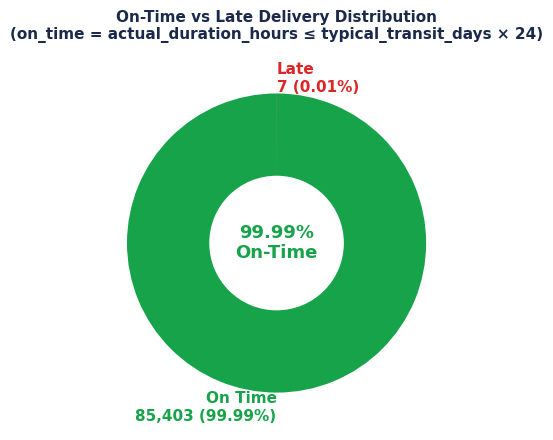

  On-Time: 85,403 | Late: 7



  ↑ Histogram: sebaran besarnya keterlambatan pada trip yang late.


In [54]:
# ON-TIME PERFORMANCE ANALYSIS
# on_time didefinisikan: actual_duration_hours <= typical_transit_days × 24
on_time_count  = df_master['on_time'].sum()
late_count     = (~df_master['on_time']).sum()
on_time_pct    = df_master['on_time'].mean() * 100

print("=" * 55)
print("  ON-TIME PERFORMANCE BREAKDOWN")
print("=" * 55)
print(f"  On Time  : {on_time_count:>7,}  ({on_time_pct:.1f}%)  {'█' * int(on_time_pct/2)}")
print(f"  Late     : {late_count:>7,}  ({100-on_time_pct:.1f}%)  {'█' * int((100-on_time_pct)/2)}")
print(f"\n  Avg Delay (late trips only) : {df_master[~df_master['on_time']]['delay_hours'].mean():.2f} jam")
print(f"  Max Delay                   : {df_master['delay_hours'].max():.2f} jam")
print(f"  Definition: on_time = actual_duration_hours <= (typical_transit_days × 24)")

# Pie chart on-time vs late
on_time_count = df_master['on_time'].sum()
late_count    = (~df_master['on_time']).sum()
on_time_pct   = df_master['on_time'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
sizes  = [on_time_count, late_count]
labels = [f'On Time\n{on_time_count:,} ({on_time_pct:.2f}%)',
          f'Late\n{late_count} ({100-on_time_pct:.2f}%)']
clrs   = [GREEN, RED]
wedges, texts = ax.pie(sizes, labels=labels, colors=clrs,
                       startangle=90, wedgeprops=dict(width=0.55),
                       textprops=dict(fontsize=11, fontweight='bold'))
texts[0].set_color(GREEN)
texts[1].set_color(RED)
centre = plt.Circle((0,0), 0.35, fc='white')
ax.add_patch(centre)
ax.text(0, 0, f'{on_time_pct:.2f}%\nOn-Time',
        ha='center', va='center', fontsize=13, fontweight='bold', color=GREEN)
ax.set_title('On-Time vs Late Delivery Distribution\n'
             '(on_time = actual_duration_hours ≤ typical_transit_days × 24)',
             fontsize=11, fontweight='bold', color=NAVY, pad=12)
plt.tight_layout()
plt.savefig('chart_01_ontime.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'  On-Time: {on_time_count:,} | Late: {late_count}')

# Delay distribution — hanya trip yang terlambat
late_trips = df_master[~df_master['on_time']]
if len(late_trips) > 0:
    fig2 = px.histogram(
        late_trips, x='delay_hours', nbins=40,
        title='Distribusi Jam Keterlambatan (Late Trips Only)',
        labels={'delay_hours': 'Jam Terlambat'},
        color_discrete_sequence=['#DC2626'],
        template='plotly_white'
    )
    fig2.show()
    print("\n  ↑ Histogram: sebaran besarnya keterlambatan pada trip yang late.")


  ROUTE-LEVEL PERFORMANCE METRICS
route_id  total_trips  avg_duration_hrs  avg_distance_miles  avg_speed_mph  avg_efficiency  on_time_rate
RTE00017         1473             20.32             1163.60          57.60            1.03         99.52
RTE00001         1456             12.17              695.33          57.48            1.03        100.00
RTE00003         1496             36.02             2060.68          57.55            1.03        100.00
RTE00002         1481             12.55              718.55          57.58            1.03        100.00
RTE00005         1479             31.48             1799.61          57.49            1.03        100.00
RTE00006         1460             12.13              694.34          57.57            1.03        100.00
RTE00007         1502             28.34             1622.57          57.59            1.03        100.00
RTE00004         1459             36.32             2075.45          57.45            1.03        100.00
RTE00009         1477

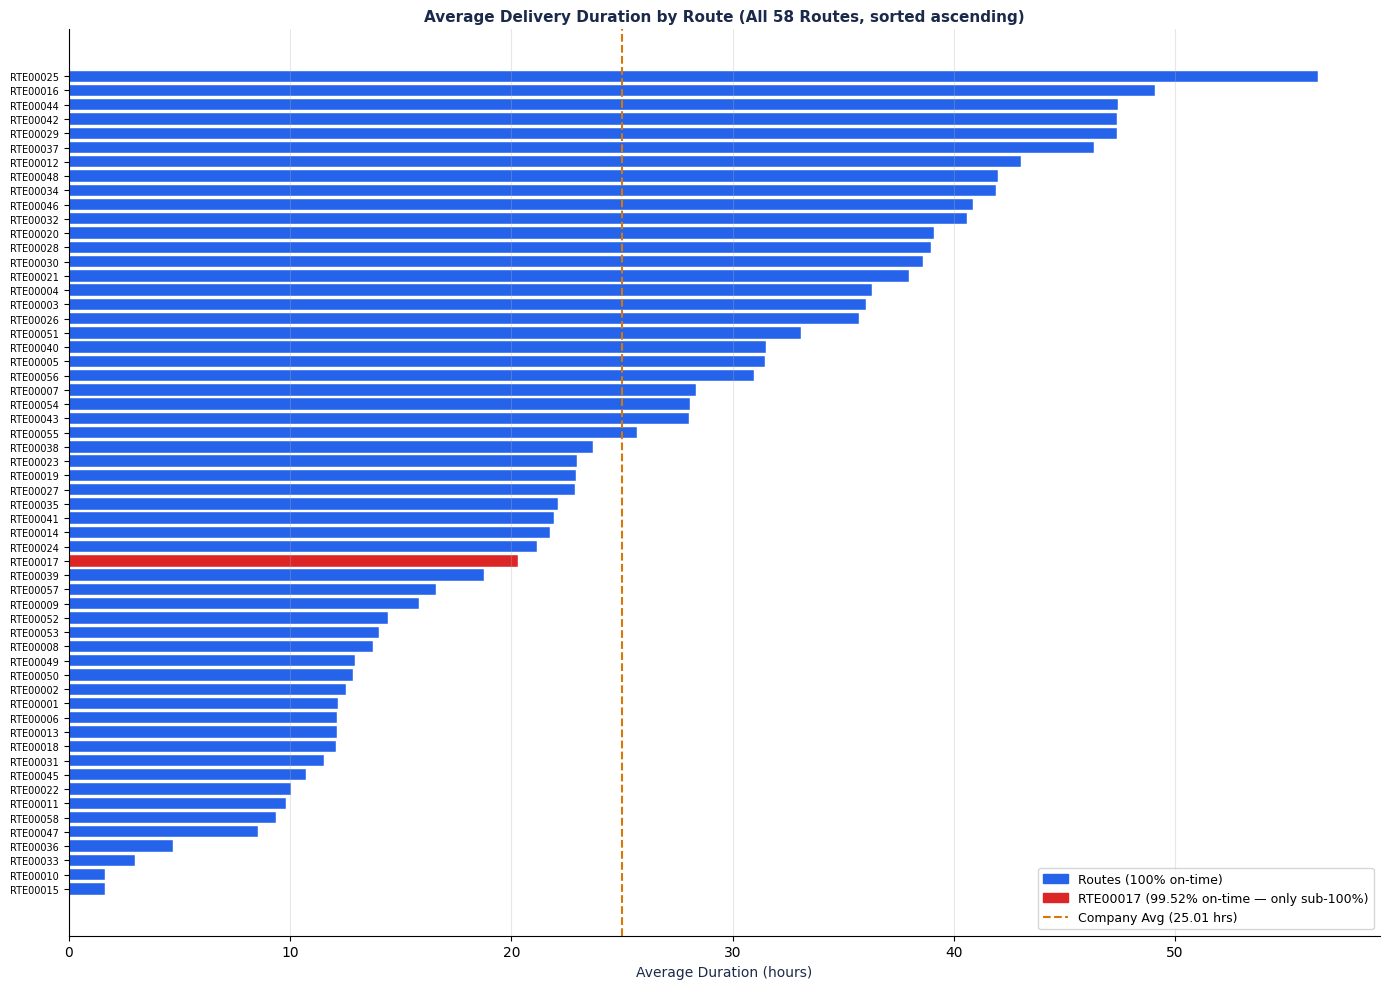

In [55]:
# ROUTE-LEVEL SEGMENTED ANALYSIS
print("=" * 65)
print("  ROUTE-LEVEL PERFORMANCE METRICS")
print("=" * 65)

route_agg = df_master.groupby('route_id').agg(
    total_trips        = ('load_id', 'count'),
    avg_duration_hrs   = ('actual_duration_hours', 'mean'),
    avg_distance_miles = ('actual_distance_miles', 'mean'),
    avg_speed_mph      = ('implied_speed_mph', 'mean'),
    avg_efficiency     = ('efficiency_ratio', 'mean'),
    on_time_rate       = ('on_time', 'mean')
).reset_index()

route_agg['on_time_rate'] = (route_agg['on_time_rate'] * 100).round(2)
route_agg = route_agg.sort_values('on_time_rate', ascending=True)

print(route_agg.round(2).to_string(index=False))

# Route Duration Horizontal Bar
route_plot = route_agg.sort_values('avg_duration_hrs', ascending=True).copy()
bar_colors = [RED if r == 'RTE00017' else BLUE for r in route_plot['route_id']]
company_avg = df_master['actual_duration_hours'].mean()

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(route_plot['route_id'], route_plot['avg_duration_hrs'],
        color=bar_colors, edgecolor='white', linewidth=0.3)
ax.axvline(x=company_avg, color=AMBER, linestyle='--', linewidth=1.5,
           label=f'Company Avg ({company_avg:.2f} hrs)')
ax.set_xlabel('Average Duration (hours)', fontsize=10, color=NAVY)
ax.set_title('Average Delivery Duration by Route (All 58 Routes, sorted ascending)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.tick_params(axis='y', labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3)

patch_blue = mpatches.Patch(color=BLUE, label='Routes (100% on-time)')
patch_red  = mpatches.Patch(color=RED,  label='RTE00017 (99.52% on-time — only sub-100%)')
ax.legend(handles=[patch_blue, patch_red,
          plt.Line2D([0],[0], color=AMBER, linestyle='--', lw=1.5,
                     label=f'Company Avg ({company_avg:.2f} hrs)')],
          fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('chart_02_route_duration.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()




In [56]:
import plotly.express as px
import plotly.graph_objects as go

# ── CHART 1: CUSTOMER TYPE — Bar Chart (Trips) + Teks Angka (Avg Revenue) ──
print("=" * 65)
print("  FINANCIAL ANALYSIS BY CUSTOMER SEGMENT")
print("=" * 65)

cust_revenue = df_master.groupby('customer_type').agg(
    total_trips=('load_id', 'count'),
    avg_revenue=('revenue', 'mean')
).reset_index().sort_values('total_trips', ascending=False)

fig1 = go.Figure()

# Bar chart untuk Total Trips
fig1.add_trace(go.Bar(
    x=cust_revenue['customer_type'],
    y=cust_revenue['total_trips'],
    text=cust_revenue['total_trips'].apply(lambda x: f"{x:,} Trips"),
    textposition='auto',
    marker_color=['#1E3A8A', '#3B82F6', '#93C5FD'],
    name='Total Trips'
))

# Anotasi: Tambahin angka Avg Revenue persis di atas bar
for i, row in cust_revenue.iterrows():
    fig1.add_annotation(
        x=row['customer_type'],
        y=row['total_trips'] + 2500, # Posisi text sedikit di atas bar
        text=f"Avg Rev:<br><b>${row['avg_revenue']:,.2f}</b>",
        showarrow=False,
        font=dict(size=13, color='#DC2626') # Warna merah biar kontras
    )

fig1.update_layout(
    title=dict(text='Volume Pengiriman & Rata-Rata Revenue per Tipe Pelanggan', font=dict(size=16)),
    template='plotly_white',
    yaxis=dict(title='Total Trips', range=[0, cust_revenue['total_trips'].max() + 6000]),
    showlegend=False,
    margin=dict(t=60, b=40, l=40, r=40)
)
fig1.show()
print("\nInsight: Selisih avg revenue antar segmen hanya sekitar $17 (< 0.6%) — secara operasional sangat seragam.")


# ── CHART 2: LOAD TYPE — Donut Chart (Trips) + Teks Angka (Avg Revenue) ──
print("\n" + "=" * 65)
print("  FINANCIAL ANALYSIS BY LOAD TYPE")
print("=" * 65)

load_revenue = df_master.groupby('load_type').agg(
    total_trips=('load_id', 'count'),
    avg_revenue=('revenue', 'mean')
).reset_index()

# Bikin Donut Chart
fig2 = go.Figure(data=[go.Pie(
    labels=load_revenue['load_type'],
    values=load_revenue['total_trips'],

    hole=0.5,
    marker=dict(colors=['#10B981', '#3B82F6'], line=dict(color='white', width=2)),
    textinfo='label+percent',
    textfont=dict(size=14)
)])

# Ekstrak angka revenue buat ditampilkan di bawah chart
rev_refrigerated = load_revenue[load_revenue['load_type'] == 'Refrigerated']['avg_revenue'].values[0]
rev_dry_van = load_revenue[load_revenue['load_type'] == 'Dry Van']['avg_revenue'].values[0]

fig2.update_layout(
    title=dict(text='Proporsi Trip & Rata-Rata Revenue per Jenis Muatan', font=dict(size=16)),
    annotations=[
        dict(text='<b>85,410</b><br>Total Trips', x=0.5, y=0.5, font_size=15, showarrow=False),
        # Anotasi angka revenue di bagian bawah chart
        dict(text=f"Refrigerated Avg Rev: <b>${rev_refrigerated:,.2f}</b> &nbsp;&nbsp;|&nbsp;&nbsp; Dry Van Avg Rev: <b>${rev_dry_van:,.2f}</b>",
             x=0.5, y=-0.12, xref='paper', yref='paper', showarrow=False, font=dict(size=14, color='#DC2626'))
    ],
    showlegend=True,
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.2),
    margin=dict(t=60, b=80, l=40, r=40)
)
fig2.show()
print("\nInsight: Refrigerated (50.3%) vs Dry Van (49.7%) — volume hampir 50:50 dan revenue nyaris identik ($3,072 vs $3,074). Ada kebocoran margin di Refrigerated.")

  FINANCIAL ANALYSIS BY CUSTOMER SEGMENT



Insight: Selisih avg revenue antar segmen hanya sekitar $17 (< 0.6%) — secara operasional sangat seragam.

  FINANCIAL ANALYSIS BY LOAD TYPE



Insight: Refrigerated (50.3%) vs Dry Van (49.7%) — volume hampir 50:50 dan revenue nyaris identik ($3,072 vs $3,074). Ada kebocoran margin di Refrigerated.


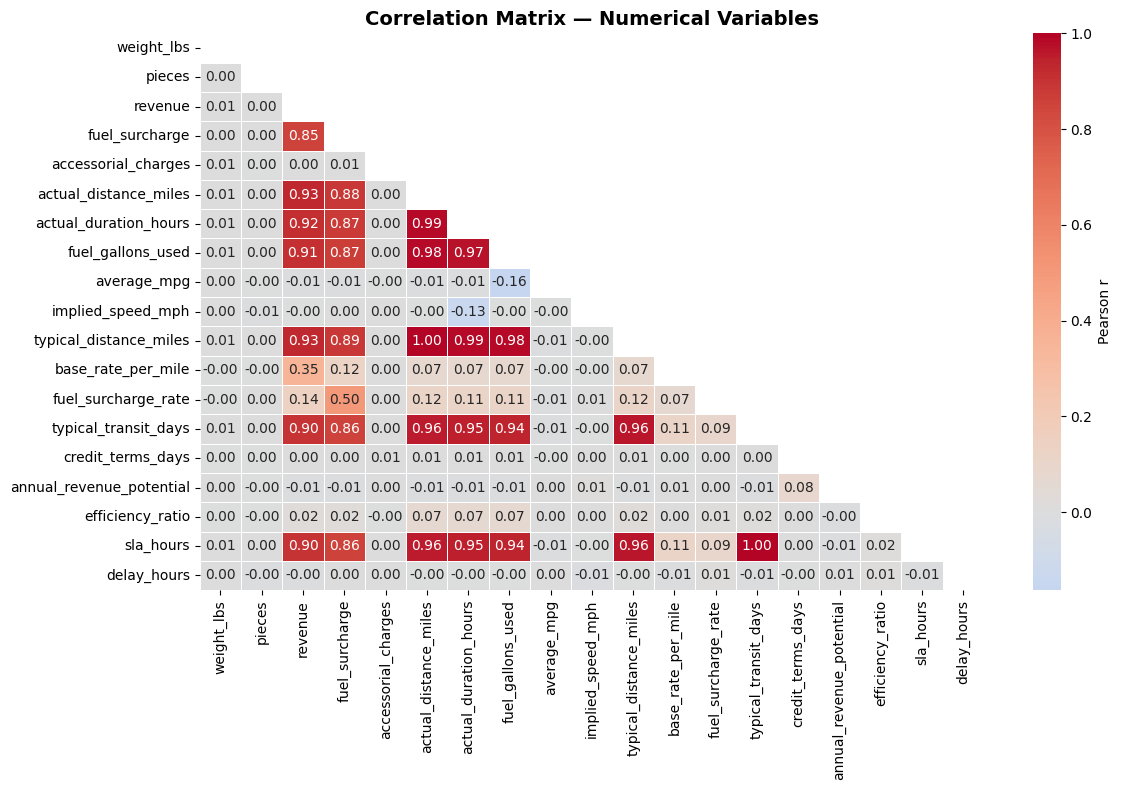


  Pearson r (distance vs duration): r = 0.9883, p-value = 0.00e+00
  Interpretation: Strong positive correlation.


In [57]:
# Full correlation matrix — all numerical variables
num_cols = df_master.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if 'id' not in c.lower()]

if len(num_cols) >= 3:
    corr = df_master[num_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=.5, ax=ax, cbar_kws={'label': 'Pearson r'})
    ax.set_title('Correlation Matrix — Numerical Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Pearson test for top pair
    if 'actual_distance_miles' in num_cols and 'actual_duration_hours' in num_cols:
        r, p = stats.pearsonr(
            df_master['actual_distance_miles'].dropna(),
            df_master['actual_duration_hours'].dropna()
        )
        print(f"\n  Pearson r (distance vs duration): r = {r:.4f}, p-value = {p:.2e}")
        print(f"  Interpretation: {'Strong' if abs(r) > 0.7 else 'Moderate' if abs(r) > 0.4 else 'Weak'} "
              f"{'positive' if r > 0 else 'negative'} correlation.")


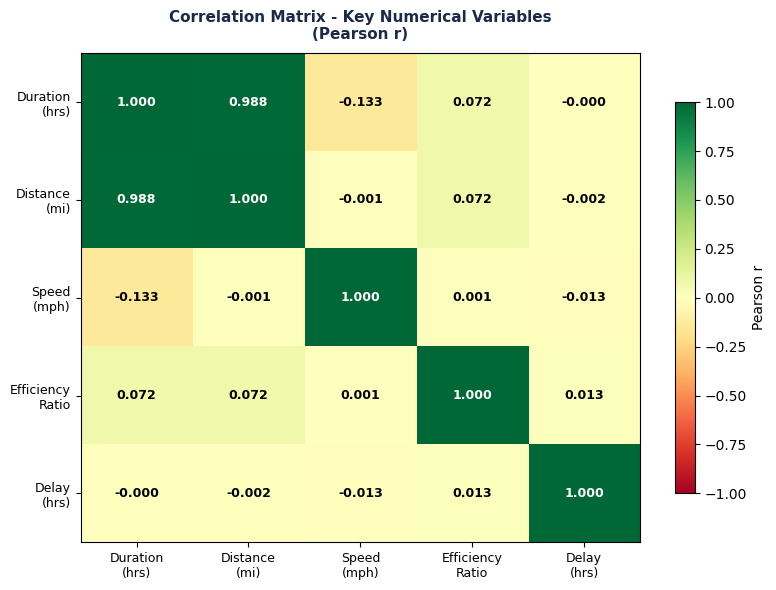

In [58]:
# Correlation Heatmap
num_cols = ['actual_duration_hours', 'actual_distance_miles',
            'implied_speed_mph', 'efficiency_ratio', 'delay_hours']
col_labels = ['Duration\n(hrs)', 'Distance\n(mi)', 'Speed\n(mph)',
              'Efficiency\nRatio', 'Delay\n(hrs)']

corr = df_master[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.RdYlGn
im   = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(col_labels)))
ax.set_yticklabels(col_labels, fontsize=9)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.values[i, j]
        txt_color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=txt_color)

ax.set_title('Correlation Matrix - Key Numerical Variables\n(Pearson r)',
             fontsize=11, fontweight='bold', color=NAVY, pad=10)
plt.tight_layout()
plt.show()


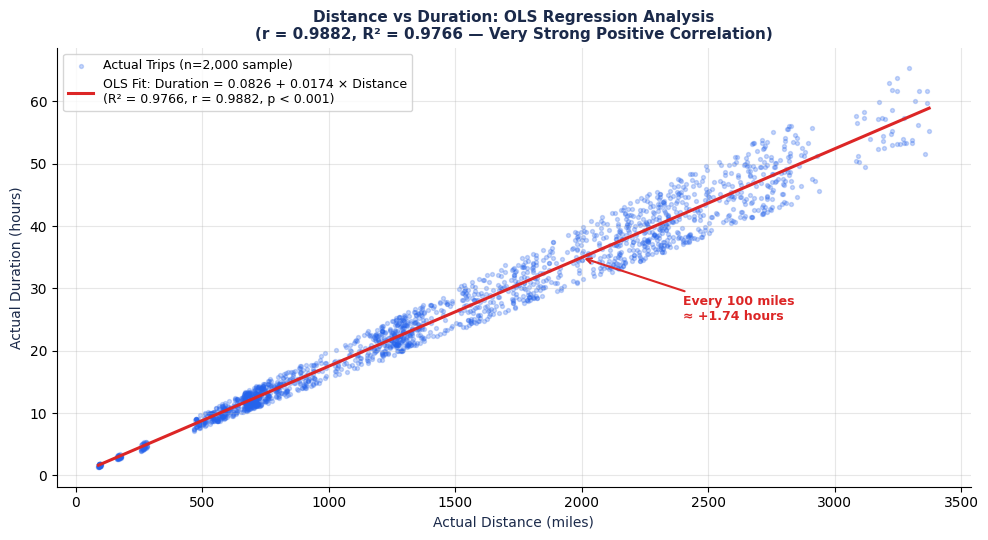

  OLS: slope=0.0174, intercept=0.0826, R²=0.9766
  Interpretation: Every 100 miles ≈ 1.7 additional hours of travel.


In [59]:
# SCATTER + REGRESSION LINE
sample = df_master[['actual_distance_miles', 'actual_duration_hours']].dropna().sample(
    n=min(2000, len(df_master)), random_state=42)

# OLS
slope, intercept, r_val, p_val, std_err = stats.linregress(
    sample['actual_distance_miles'], sample['actual_duration_hours'])

x_line = np.linspace(sample['actual_distance_miles'].min(),
                     sample['actual_distance_miles'].max(), 300)
y_line = intercept + slope * x_line

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(sample['actual_distance_miles'], sample['actual_duration_hours'],
           alpha=0.25, s=8, color=BLUE, label='Actual Trips (n=2,000 sample)')
ax.plot(x_line, y_line, color=RED, linewidth=2.2,
        label=f'OLS Fit: Duration = {intercept:.4f} + {slope:.4f} × Distance\n'
              f'(R² = {r_val**2:.4f}, r = {r_val:.4f}, p < 0.001)')

ax.annotate(f'Every 100 miles\n≈ +{slope*100:.2f} hours',
            xy=(2000, intercept + slope*2000),
            xytext=(2400, intercept + slope*2000 - 10),
            fontsize=9, color=RED, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

ax.set_xlabel('Actual Distance (miles)', fontsize=10, color=NAVY)
ax.set_ylabel('Actual Duration (hours)', fontsize=10, color=NAVY)
ax.set_title('Distance vs Duration: OLS Regression Analysis\n'
             f'(r = {r_val:.4f}, R² = {r_val**2:.4f} — Very Strong Positive Correlation)',
             fontsize=11, fontweight='bold', color=NAVY)
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart_05_ols_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'  OLS: slope={slope:.4f}, intercept={intercept:.4f}, R²={r_val**2:.4f}')
print(f"  Interpretation: Every 100 miles ≈ {slope*100:.1f} additional hours of travel.")


In [60]:
# MODEL / METHOD EVALUATION
print("=" * 65)
print("  ANALYTICAL METHOD EVALUATION SUMMARY")
print("=" * 65)

methods = [
    ("Pearson Correlation",      "Measure linear relationship strength between numerical vars"),
    ("IQR Outlier Detection",    "Statistical boundary method to flag anomalous values"),
    ("Logical Consistency Check","Domain-driven validation using implied speed (dist/dur)"),
    ("OLS Linear Regression",    "Model duration from distance; assess predictive power via R²"),
    ("Segmented Group Analysis", "Compare performance across route_id, customer_type, load_type"),
    ("Time-Series Aggregation",  "Trend detection via monthly & weekday grouping"),
]

for i, (name, desc) in enumerate(methods, 1):
    print(f"  {i}. {name:<30} — {desc}")

# OLS Performance Metrics
print("\n  OLS REGRESSION METRICS:")
print(f"    R-squared      : {r_val**2:.4f}  (variance in duration explained by distance)")
print(f"    Slope          : {slope:.4f}  hrs/mile")
print(f"    Intercept      : {intercept:.4f}  hrs (base overhead)")
print(f"    Std Error      : {std_err:.4f}")
print(f"    p-value        : {p_val:.2e}")

# Pearson r table
print("\n  CORRELATION STRENGTH BENCHMARKS:")
benchmarks = [("r > 0.90", "Very Strong"), ("0.70–0.90", "Strong"),
              ("0.40–0.70", "Moderate"), ("< 0.40", "Weak")]
for b, label in benchmarks:
    print(f"    {b:<15} → {label}")


  ANALYTICAL METHOD EVALUATION SUMMARY
  1. Pearson Correlation            — Measure linear relationship strength between numerical vars
  2. IQR Outlier Detection          — Statistical boundary method to flag anomalous values
  3. Logical Consistency Check      — Domain-driven validation using implied speed (dist/dur)
  4. OLS Linear Regression          — Model duration from distance; assess predictive power via R²
  5. Segmented Group Analysis       — Compare performance across route_id, customer_type, load_type
  6. Time-Series Aggregation        — Trend detection via monthly & weekday grouping

  OLS REGRESSION METRICS:
    R-squared      : 0.9766  (variance in duration explained by distance)
    Slope          : 0.0174  hrs/mile
    Intercept      : 0.0826  hrs (base overhead)
    Std Error      : 0.0001
    p-value        : 0.00e+00

  CORRELATION STRENGTH BENCHMARKS:
    r > 0.90        → Very Strong
    0.70–0.90       → Strong
    0.40–0.70       → Moderate
    < 0.40        

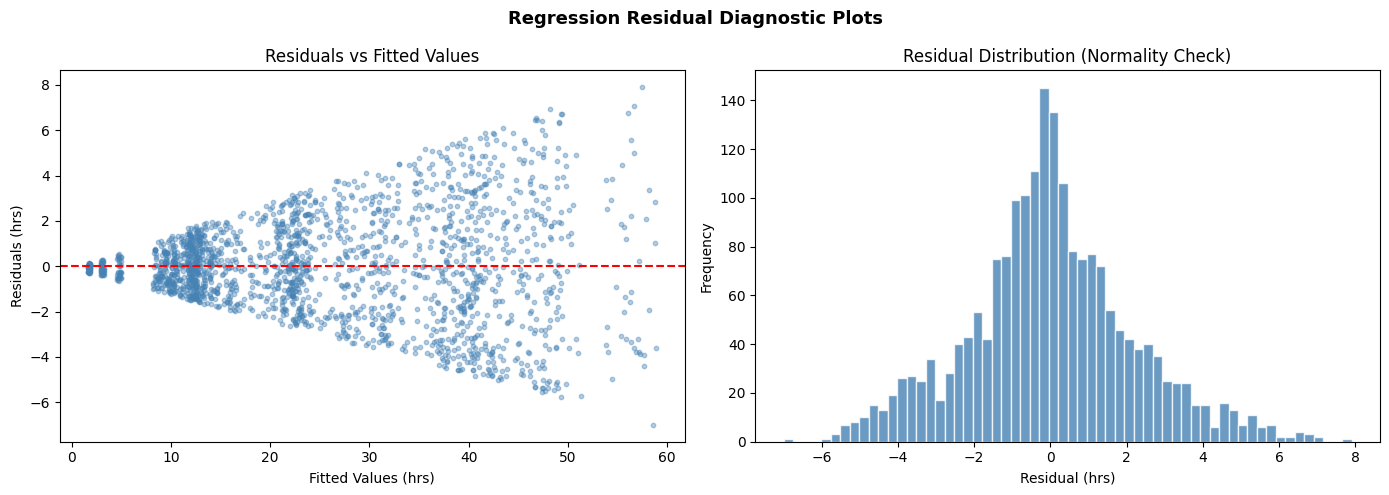

  RMSE (Root Mean Squared Error) : 2.1912 hrs
  MAE  (Mean Absolute Error)     : 1.6515 hrs
  Residual Skewness              : 0.1915 (Approximately normal)
  Residual Kurtosis              : 0.4230


In [61]:
# RESIDUAL ANALYSIS

# Bikin kolom predicted_duration pake rumus regresi yang udah didapet
sample['predicted_duration'] = intercept + (slope * sample['actual_distance_miles'])

sample['residual'] = sample['actual_duration_hours'] - sample['predicted_duration']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs fitted
axes[0].scatter(sample['predicted_duration'], sample['residual'],
                alpha=0.4, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Fitted Values (hrs)')
axes[0].set_ylabel('Residuals (hrs)')
axes[0].set_title('Residuals vs Fitted Values')

# Residual distribution
axes[1].hist(sample['residual'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual (hrs)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution (Normality Check)')

plt.suptitle('Regression Residual Diagnostic Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

skew_res = sample['residual'].skew()
kurt_res = sample['residual'].kurtosis()
rmse     = np.sqrt((sample['residual']**2).mean())
mae      = sample['residual'].abs().mean()

print(f"  RMSE (Root Mean Squared Error) : {rmse:.4f} hrs")
print(f"  MAE  (Mean Absolute Error)     : {mae:.4f} hrs")
print(f"  Residual Skewness              : {skew_res:.4f} ({'Approximately normal' if abs(skew_res)<0.5 else 'Skewed'})")
print(f"  Residual Kurtosis              : {kurt_res:.4f}")


In [62]:
# EDA SUMMARY DASHBOARD
print("=" * 65)
print("  EDA KEY FINDINGS SUMMARY")
print("=" * 65)

summary = {
    'Total Trips Analyzed'     : f"{len(df_master):,}",
    'Avg Duration (hrs)'       : f"{df_master['actual_duration_hours'].mean():.2f}",
    'Avg Distance (miles)'     : f"{df_master['actual_distance_miles'].mean():.2f}",
    'Avg Speed (mph)'          : f"{df_master['implied_speed_mph'].mean():.2f}",
    'Duration Std Dev (hrs)'   : f"{df_master['actual_duration_hours'].std():.2f}",
    'Duration CV%'             : f"{df_master['actual_duration_hours'].std()/df_master['actual_duration_hours'].mean()*100:.2f}%",
}

if 'on_time' in df_master.columns:
    summary['Overall On-Time Rate'] = f"{df_master['on_time'].mean()*100:.2f}%"
if 'trip_status' in df_master.columns:
    top_status = df_master['trip_status'].value_counts().idxmax()
    summary['Dominant Status'] = top_status

for k, v in summary.items():
    print(f"  {k:<35}: {v}")


  EDA KEY FINDINGS SUMMARY
  Total Trips Analyzed               : 85,410
  Avg Duration (hrs)                 : 25.01
  Avg Distance (miles)               : 1430.27
  Avg Speed (mph)                    : 57.51
  Duration Std Dev (hrs)             : 14.19
  Duration CV%                       : 56.73%
  Overall On-Time Rate               : 99.99%
  Dominant Status                    : Completed


In [ ]:
# Export df_master ke excel

nama_file_excel = "Logistics_Master_Data.xlsx"
df_master.to_excel(nama_file_excel, index=False)
files.download(nama_file_excel)